# Importing Libraries and Data set

In [ ]:
!pip install beautifulsoup4 pandas requests tqdm

import requests
import pandas as pd
from bs4 import BeautifulSoup
from datetime import datetime, timedelta
from urllib.parse import quote_plus
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import time

In [ ]:
# List of all fortune 500 companies that will be used
forbes = pd.read_csv('https://raw.githubusercontent.com/Dguz06/Datasets/refs/heads/main/Data580F/final%20project/Forbes%20Companies%20-%20Sheet1.csv')
companies = forbes["Company"]
companies


,Company
0,Amazon
1,Walmart
2,UnitedHealth
3,Apple
4,Alphabet
...,...
495,Electronic Arts
496,Newell Brands
497,Ingredion
498,KeyCorp


# Scraping all headlines

In [ ]:
HEADERS = {"User-Agent": "Mozilla/5.0"}


# This function collects the results for a given date and company. It will be used later whe iterating through every date and company
def fetch_day_company(date, company, max_results=10):
    time.sleep(0.052)
    next_day = date + timedelta(days=1)
    encoded_query = quote_plus(company)

    url = (
        "https://news.google.com/rss/search?"
        f"q={encoded_query}+after:{date.strftime('%Y-%m-%d')}+before:{next_day.strftime('%Y-%m-%d')}"
        "&hl=en-US&gl=US&ceid=US:en"
    )

    try:

        r = requests.get(url, headers=HEADERS, timeout=10)
        soup = BeautifulSoup(r.content, "xml")

        items = soup.find_all("item")

        seen_titles = set()
        data = []

        for item in items:

            title = item.title.text.strip()

            if title in seen_titles:
                continue

            seen_titles.add(title)

            pub_date = datetime.strptime(
                item.pubDate.text,
                "%a, %d %b %Y %H:%M:%S %Z"
            )

            source = item.source.text if item.source else None
            link = item.link.text

            data.append({
                "company": company,
                "date": pub_date.strftime("%Y-%m-%d"),
                "rank": len(data) + 1,
                "title": title,
                "source": source,
                "link": link
            })

            if len(data) >= max_results:
                break

        return data

    except:
        return []


# This function iterates through every date and company and uses the previous function to collect headlines
def scraper(companies, start_date, end_date, workers=30):

    tasks = []

    current = start_date
    while current <= end_date:

        for company in companies:
            tasks.append((current, company))

        current += timedelta(days=1)

    results = []

    with ThreadPoolExecutor(max_workers=workers) as executor:

        futures = [
            executor.submit(fetch_day_company, d, c)
            for d, c in tasks
        ]

        for f in tqdm(as_completed(futures), total=len(futures)):
            results.extend(f.result())

    df = pd.DataFrame(results)

    df.to_csv("google_news_dataset.csv", index=False)

    print("Saved dataset")
    print(df.head())

    return df

In [ ]:
df = scraper(
    companies=companies,
    start_date=datetime(2025,1,1),
    end_date=datetime(2025,12,31),
    workers=30
)

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/company_articles.csv'

df.to_csv(file_path, index=False)

# Using finBERT to get sentiment analysis

In [ ]:
import pandas as pd
data = pd.read_csv("company_articles.csv")

In [ ]:
# creating tokenizer and model
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
model = AutoModelForSequenceClassification.from_pretrained("ProsusAI/finbert")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
# This cell applies finBERT to every headline and collects the positiv/neutral/negative scores
# This had to be done in batches because the code kept crashing before it could all finish

import torch
import pandas as pd
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model.to(device)
model.eval()

chunk_size = 2000
batch_size = 16
output_dir = "chunks"

os.makedirs(output_dir, exist_ok=True)

num_rows = len(data)

for start in range(0, num_rows, chunk_size):
    end = start + chunk_size
    chunk_file = f"{output_dir}/chunk_{start}.csv"

    if os.path.exists(chunk_file):
        print(f"Skipping {start}-{end} (already done)")
        continue

    print(f"Processing rows {start} to {end}")

    chunk = data.iloc[start:end].copy()
    texts = chunk["title"].fillna("").astype(str).tolist()

    all_preds = []

    with torch.no_grad():
      for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.cuda.amp.autocast():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        all_preds.append(probs.cpu())

    preds = torch.cat(all_preds).numpy()

    chunk["negative"] = preds[:, 0]
    chunk["neutral"]  = preds[:, 1]
    chunk["positive"] = preds[:, 2]

    chunk.to_csv(chunk_file, index=False)


In [ ]:
# Combining batches
import glob
import pandas as pd

files = sorted(glob.glob("chunks/chunk_*.csv"))
final_df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

In [ ]:
# Exporting
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/sentiment.csv'

final_df.to_csv(file_path, index=False)

# Cleaning sentiment data

In [ ]:
# If uploading
sentiment = pd.read_csv("sentiment.csv")

In [ ]:
# Filtering so its only companies with at least 330+ days of 5+ articles

sentiment_data = (
    sentiment.assign(
        Date=pd.to_datetime(sentiment["date"]).dt.date,
        difference=sentiment["positive"] - sentiment["negative"]
    )

    .groupby(["company", "Date"])
    .filter(lambda x: len(x) >= 5)

    .groupby(["company", "Date"])[["positive", "negative", "difference"]]
    .mean()
    .reset_index()

    .groupby("company")
    .filter(lambda x: len(x) >= 330)

    .rename(columns={
        "positive": "Average Positive",
        "negative": "Average Negative",
        "difference": "Average Difference"
    })
)

In [ ]:
# Assigning each company a ticker to be used later with yahoo finance library
ticker_map = {
    "1 Automotive": "GPI",
    "3M": "MMM",
    "Airbnb": "ABNB",
    "American Airlines": "AAL",
    "American International": "AIG",
    "Andersons": "ANDE",
    "Apple": "AAPL",
    "Ball": "BALL",
    "Bank of America": "BAC",
    "Berkshire Hathaway": "BRK-B",
    "Best Buy": "BBY",
    "Caesars Entertainment": "CZR",
    "Campbell's": "CPB",
    "Capital One": "COF",
    "Carrier Global": "CARR",
    "Coca-Cola": "KO",
    "Crown": "CCK",
    "Cummins": "CMI",
    "Dana": "DAN",
    "Deere": "DE",
    "Dollar General": "DG",
    "Dover": "DOV",
    "Ebay": "EBAY",
    "Endeavor": "EDR",
    "FM": "FMCC",
    "Ferguson": "FERG",
    "Fox": "FOX",
    "Gap": "GAP",
    "General Electric": "GE",
    "Guardian Life": None,
    "HP": "HPQ",
    "Jacobs Solutions": "J",
    "Lockheed Martin": "LMT",
    "Lowe's": "LOW",
    "Marriott International": "MAR",
    "McDonald's": "MCD",
    "Mosaic": "MOS",
    "Murphy USA": "MUSA",
    "Nike": "NKE",
    "Nordstrom": "JWN",
    "Northrop Grumman": "NOC",
    "Nvidia": "NVDA",
    "Oscar Health": "OSCR",
    "PayPal": "PYPL",
    "Post": "POST",
    "Progressive": "PGR",
    "RTX": "RTX",
    "Reliance": "RS",
    "Sirius XM": "SIRI",
    "Southern": "SO",
    "Southwest Airlines": "LUV",
    "State Farm": None,
    "Tesla": "TSLA",
    "Travelers": "TRV",
    "Uber": "UBER",
    "United Airlines": "UAL",
    "Walmart": "WMT",
    "Walt Disney": "DIS",
    "Williams": "WMB"
}

sentiment_data["ticker"] = sentiment_data["company"].map(ticker_map)

sentiment_data = sentiment_data.dropna(subset=["ticker"])

In [ ]:
# creating dataframe to be used for modeling. Taking the closing price from yf library as well as calculating the price change rate
import yfinance as yf

sentiment_data["Date"] = pd.to_datetime(sentiment_data["Date"])

tickers = sentiment_data["ticker"].dropna().unique().tolist()

bad_tickers = ["JWN", "EDR"]
tickers = [t for t in tickers if t not in bad_tickers]

price_data = yf.download(
    tickers=tickers,
    start=sentiment_data["Date"].min(),
    end=sentiment_data["Date"].max(),
    group_by="ticker",
    auto_adjust=False,
    progress=True
)

price_list = []

for ticker in tickers:
    try:
        df = price_data[ticker][["Close"]].reset_index()
        df["ticker"] = ticker
        df = df.rename(columns={"Close": "Close Price"})
        price_list.append(df)
    except:
        print(f"Skipping {ticker}")

price_df = pd.concat(price_list, ignore_index=True)

price_df["Date"] = pd.to_datetime(price_df["Date"])

final_df = sentiment_data.merge(
    price_df,
    on=["ticker", "Date"],
    how="left"
)

final_df = final_df.sort_values(["ticker", "Date"])
final_df["Close Price"] = final_df.groupby("ticker")["Close Price"].ffill()

final_df["next_close"] = final_df.groupby("ticker")["Close Price"].shift(-1)

final_df["next_return"] = (
    (final_df["next_close"] - final_df["Close Price"])
    / final_df["Close Price"])

# Looking at "Trump" News

In [ ]:
trump_df = scraper(
    companies=["Trump"],
    start_date=datetime(2025,1,1),
    end_date=datetime(2025,12,31),
    workers=30
)

100%|██████████| 365/365 [00:17<00:00, 21.35it/s]

Saved dataset
  company        date  rank  \
0   Trump  2025-01-04     1   
1   Trump  2025-01-02     1   
2   Trump  2025-01-03     2   
3   Trump  2025-01-03     3   
4   Trump  2025-01-02     4   

                                               title  \
0  Trump Has Reeled in More Than $200 Million Sin...   
1  Trump Tax Cuts Revived American Manufacturing ...   
2  Transition 2025: What Will Donald Trump Do Abo...   
3  Trump Pardoning Jan. 6 Insurrectionists Would ...   
4  Highest Hopes for Trump on Immigration; Lowest...   

                         source  \
0            The New York Times   
1         Ways and Means (.gov)   
2  Council on Foreign Relations   
3    Brennan Center for Justice   
4                   Gallup News   

                                                link  
0  https://news.google.com/rss/articles/CBMigwFBV...  
1  https://news.google.com/rss/articles/CBMikgFBV...  
2  https://news.google.com/rss/articles/CBMiiAFBV...  
3  https://news.google.com/rss/

In [ ]:
import torch
import pandas as pd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model.to(device)
model.eval()

batch_size = 16  # keep this!

texts = trump_df["title"].fillna("").astype(str).tolist()
all_preds = []

print(f"Processing {len(texts)} rows...")

with torch.no_grad():
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}

        with torch.cuda.amp.autocast():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        all_preds.append(probs.cpu())

preds = torch.cat(all_preds).numpy()

trump_df["negative"] = preds[:, 0]
trump_df["neutral"]  = preds[:, 1]
trump_df["positive"] = preds[:, 2]

cpu
Processing 3622 rows...


/tmp/ipykernel_4216/3539093572.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(


In [ ]:
trump_data = (
    trump_df.assign(
        Date=pd.to_datetime(trump_df["date"]).dt.date,
        difference=trump_df["positive"] - trump_df["negative"]
    )

    .groupby(["company", "Date"])[["positive", "negative", "difference"]]
    .mean()
    .reset_index()

    .rename(columns={
        "positive": "Average Positive",
        "negative": "Average Negative",
        "difference": "Average Difference Trump"
    })
)

trump_data["Average Difference Trump"] = trump_data.groupby("Date")["Average Difference Trump"].ffill()

In [ ]:
trump_data['Date'] = pd.to_datetime(trump_data['Date'])

sept_30 = pd.Timestamp('2025-09-30')
filtered_df = trump_data[trump_data['Date'] > sept_30]
filtered_df.sort_values(by="Average Difference Trump")

,company,Date,Average Positive,Average Negative,Average Difference Trump
280,Trump,2025-10-11,0.501469,0.285539,0.215930
295,Trump,2025-10-26,0.552985,0.320519,0.232466
291,Trump,2025-10-22,0.308432,0.040292,0.268140
275,Trump,2025-10-06,0.457301,0.151997,0.305304
270,Trump,2025-10-01,0.375115,0.060096,0.315019
...,...,...,...,...,...
336,Trump,2025-12-06,0.861081,0.059983,0.801098
302,Trump,2025-11-02,0.851505,0.048175,0.803330
276,Trump,2025-10-07,0.866731,0.056382,0.810348
339,Trump,2025-12-09,0.881373,0.044705,0.836668


In [ ]:
sentiment_data = pd.read_csv("sentiment_data.csv")

price_data = sentiment_data.drop(
    columns=["Average Positive", "Average Negative"]
)

price_data['Date'] = pd.to_datetime(price_data['Date'])
trump_data['Date'] = pd.to_datetime(trump_data['Date'])

trump_data = price_data.merge(
    trump_data[['Date', 'Average Difference Trump']],
    on='Date',
    how='left'
)

In [ ]:
import pandas as pd
import numpy as np

def consolidate_weekend_sentiment(df):
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])

    df['day_of_week'] = df['Date'].dt.dayofweek


    df['effective_date'] = df['Date']
    df.loc[df['day_of_week'] == 5, 'effective_date'] = df['Date'] - pd.Timedelta(days=1)
    df.loc[df['day_of_week'] == 6, 'effective_date'] = df['Date'] - pd.Timedelta(days=2)


    agg_logic = {}

    # Sentiment columns: Average if they exist
    potential_sent_cols = ['Average Difference', 'Average Difference Trump', 'Average Positive', 'Average Negative']
    for col in potential_sent_cols:
        if col in df.columns:
            agg_logic[col] = 'mean'


    price_cols = {
        'Close Price': 'first',   # Friday's price
        'next_close': 'last',    # Target price (Monday)
        'next_return': 'last',   # Target return (Monday)
        'company': 'first'
    }

    for col, method in price_cols.items():
        if col in df.columns:
            agg_logic[col] = method


    # group by ticker and the effective date
    df_clean = df.groupby(['ticker', 'effective_date']).agg(agg_logic).reset_index()


    df_clean = df_clean.rename(columns={'effective_date': 'Date'})

    # filtering out weekends
    df_clean['day_of_week'] = df_clean['Date'].dt.dayofweek
    df_clean = df_clean[df_clean['day_of_week'] < 5]

    return df_clean.sort_values(['ticker', 'Date']).drop(columns=['day_of_week'])


df_final = consolidate_weekend_sentiment(trump_data)


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/news_final.csv'

df_final.to_csv(file_path, index=False)

Mounted at /content/drive


# Created GRU models and getting evaluation metrics

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import random
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed

def unified_gru_pipeline(
    df,
    sequence_length=7,
    n_splits=3,
    mc_samples=5,
    dropout_rate=0.2,
    threshold=0.001,
    n_jobs=-1
):
    def set_seed(seed=0):
        np.random.seed(seed)
        tf.random.set_seed(seed)
        random.seed(seed)

    def get_metrics(y_true, y_pred, y_train_naive):
        da = np.mean(np.sign(y_true) == np.sign(y_pred))
        rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
        denom = np.mean(np.abs(y_train_naive[1:] - y_train_naive[:-1]))
        mase_val = np.mean(np.abs(y_true - y_pred)) / denom if denom != 0 else np.nan
        sp, _ = spearmanr(y_true, y_pred)
        sp = 0 if np.isnan(sp) else sp
        strat_ret = np.sign(y_pred) * y_true
        total_ret = np.prod(1 + strat_ret) - 1
        return rmse, mase_val, da, sp, total_ret

    def build_sequences(values, targets, seq_len):
        X = np.lib.stride_tricks.sliding_window_view(
            values, (seq_len, values.shape[1])
        )[:-1, 0]
        y = targets[seq_len:]
        return X.astype(np.float32), y.astype(np.float32)

    def build_model(input_shape):
        inputs = tf.keras.Input(shape=input_shape)
        x = tf.keras.layers.GRU(32, dropout=dropout_rate)(inputs)
        x = tf.keras.layers.Dropout(dropout_rate)(x)
        outputs = tf.keras.layers.Dense(1)(x)
        model = tf.keras.Model(inputs, outputs)
        model.compile(optimizer="adam", loss="mse")
        return model

    # Preprocessing
    df = df.copy().sort_values(["ticker", "Date"])
    df["next_return"] = df.groupby("ticker")["Close Price"].pct_change()
    df["target"] = df.groupby("ticker")["next_return"].shift(-1)

    # Define the 6 specific models
    model_configs = {
        "price_only": ["next_return"],
        "sentiment_only": ["Average Difference"],
        "trump_only": ["Average Difference Trump"],
        "price_and_sentiment": ["next_return", "Average Difference"],
        "trump_and_price": ["next_return", "Average Difference Trump"],
        "combined": ["next_return", "Average Difference", "Average Difference Trump"]
    }
    # applying models to each company
    def process_ticker(ticker, sub):
        ticker_results = []
        for model_name, features in model_configs.items():
            sub_clean = sub.dropna(subset=features + ["target"])

            if len(sub_clean) < sequence_length + 30:
                continue

            values = sub_clean[features].values
            targets = sub_clean["target"].values
            dates = sub_clean["Date"].values

            X, y = build_sequences(values, targets, sequence_length)
            dates_aligned = dates[sequence_length:]

            # Split logic
            n = len(X)
            split_idx = n // (n_splits + 1)
            train_end = split_idx * n_splits

            X_train, y_train = X[:train_end], y[:train_end]
            X_test, y_test = X[train_end:], y[train_end:]
            dates_test = dates_aligned[train_end:]

            if len(X_test) == 0: continue

            # Scaling
            scaler = StandardScaler()
            X_train_s = scaler.fit_transform(X_train.reshape(-1, X_train.shape[-1])).reshape(X_train.shape)
            X_test_s = scaler.transform(X_test.reshape(-1, X_test.shape[-1])).reshape(X_test.shape)

            set_seed(0)
            model = build_model((sequence_length, X.shape[2]))
            model.fit(X_train_s, y_train, epochs=3, batch_size=32, verbose=0)

            # MC Dropout Predictions
            preds_samples = [model(X_test_s, training=True).numpy().flatten() for _ in range(mc_samples)]
            y_pred = np.mean(preds_samples, axis=0)

            # Metrics and Curves
            rmse, mase_val, da, sp, p_ret = get_metrics(y_test, y_pred, y_train[-len(y_test):])
            positions = np.where(y_pred > threshold, 1, np.where(y_pred < -threshold, -1, 0))

            ticker_results.append({
                "ticker": ticker,
                "model": model_name,
                "RMSE": rmse,
                "MASE": mase_val,
                "directional_accuracy": da,
                "spearman_rank": sp,
                "portfolio_return": p_ret,
                "curve": np.cumprod(1 + positions * y_test),
                "buy_and_hold_curve": np.cumprod(1 + y_test),
                "dates": dates_test,
                "y_true": y_test,
                "y_pred": y_pred
            })
            tf.keras.backend.clear_session()
        return ticker_results

    grouped = list(df.groupby("ticker"))
    all_results = Parallel(n_jobs=n_jobs)(delayed(process_ticker)(t, s) for t, s in grouped)

    return pd.DataFrame([item for sublist in all_results for item in sublist])

In [ ]:
final_GRU_results = unified_gru_pipeline(
    df_final,
    sequence_length=7,
    n_splits=3,
    mc_samples=5,
    dropout_rate=0.2,
    threshold=0.001,
    n_jobs=-1
)

/tmp/ipykernel_4216/4140341054.py:53: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df["next_return"] = df.groupby("ticker")["Close Price"].pct_change()
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [ ]:
# Exporting
from google.colab import drive

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/total_results3.csv'

final_GRU_results.to_csv(file_path, index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Graphing indiviual companies

In [ ]:
import pandas as pd
final_results = pd.read_csv("total_results3.csv")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast

def plot_company_curves(
    df,
    ticker,
    start_date=None,
    end_date=None,
    models_to_plot=None
):
    # converting imported df format to usable format
    def parse_series(data):
        if isinstance(data, str):
            clean_str = data.replace('[', '').replace(']', '').replace("'", "")
            parts = [p for p in clean_str.split() if p.strip()]
            return np.array(parts)
        return np.array(data).flatten()

    # Filter for the specific ticker
    sub = df[df["ticker"] == ticker].copy()

    if sub.empty:
        print(f"No data for ticker: {ticker}")
        return

    plt.figure(figsize=(14, 7))

    color_map = {
        "price_only": "#95a5a6",
        "sentiment_only": "#3498db",
        "trump_only": "#e74c3c",
        "price_and_sentiment": "#f39c12",
        "trump_and_price": "#9b59b6",
        "combined": "#2ecc71",
        "buy_and_hold": "#000000"
    }

    parsed_start = pd.to_datetime(start_date) if start_date else None
    parsed_end = pd.to_datetime(end_date) if end_date else None

    if models_to_plot is None:
        models_to_plot = list(sub["model"].unique()) + ["buy_and_hold"]

    # Plot Strategy Curves
    for _, row in sub.iterrows():
        model_name = row["model"]
        if model_name not in models_to_plot:
            continue

        raw_dates = parse_series(row["dates"])
        dates = pd.to_datetime(raw_dates, errors='coerce')
        curve = parse_series(row["curve"]).astype(float)

        valid_mask = ~pd.isna(dates)
        dates, curve = dates[valid_mask], curve[valid_mask]

        # Date Filtering
        mask = np.ones(len(dates), dtype=bool)
        if parsed_start:
            mask &= (dates >= parsed_start)
        if parsed_end:
            mask &= (dates <= parsed_end)

        dates, curve = dates[mask], curve[mask]

        if len(dates) == 0:
            continue

        # Re-normalize to start at 1.0 for the visible period
        if curve[0] != 0:
            curve = curve / curve[0]

        plt.plot(
            dates,
            curve,
            label=model_name,
            color=color_map.get(model_name),
            linewidth=2,
            alpha=0.8
        )

    # Plot actual stock
    if "buy_and_hold" in models_to_plot:
        sample_row = sub.iloc[0]
        raw_dates_bh = parse_series(sample_row["dates"])
        dates_bh = pd.to_datetime(raw_dates_bh, errors='coerce')
        bh_curve = parse_series(sample_row["buy_and_hold_curve"]).astype(float)

        valid_bh = ~pd.isna(dates_bh)
        dates_bh, bh_curve = dates_bh[valid_bh], bh_curve[valid_bh]

        mask_bh = np.ones(len(dates_bh), dtype=bool)
        if parsed_start:
            mask_bh &= (dates_bh >= parsed_start)
        if parsed_end:
            mask_bh &= (dates_bh <= parsed_end)

        dates_bh, bh_curve = dates_bh[mask_bh], bh_curve[mask_bh]

        if len(dates_bh) > 0:
            if bh_curve[0] != 0:
                bh_curve = bh_curve / bh_curve[0]

            plt.plot(
                dates_bh,
                bh_curve,
                linestyle="--",
                color=color_map["buy_and_hold"],
                linewidth=2.5,
                label="Actual Stock Growth",
                zorder=1
            )

    plt.title(f"New Advancements in Footwear Look Good for Nike, Which Causes Sentiment Model to Fall", fontsize=18, pad=15)
    plt.xlabel("Date", fontsize=15)
    plt.ylabel("Portfolio Value", fontsize=15)
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

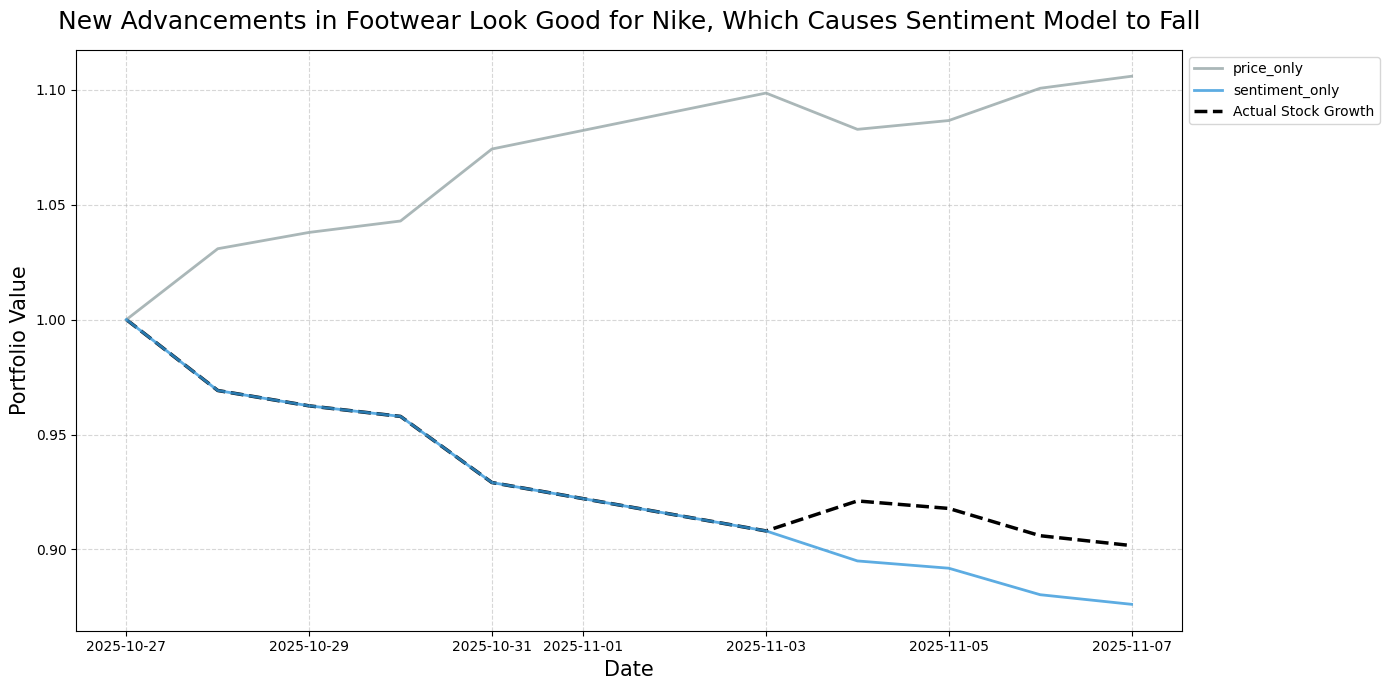

In [ ]:
plot_company_curves(
    final_GRU_results,
    "NKE",
    start_date = "2025-10-27",
    end_date = "2025-11-08",
    models_to_plot = ["sentiment_only", "buy_and_hold", "price_only"]
)

# Graphing Cumulative Portfolio

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def plot_average_curves(df):
    """
    Plots the ensemble average of all 6 models, aligned by calendar dates.
    Handles string-imported data and varying date ranges per ticker.
    """
    plt.figure(figsize=(14, 7))

    color_map = {
        "price_only": "#95a5a6",
        "sentiment_only": "#3498db",
        "trump_only": "#e74c3c",
        "price_and_sentiment": "#f39c12",
        "trump_and_price": "#9b59b6",
        "combined": "#2ecc71"
    }

    def parse_series(data, is_numeric=True):
        if isinstance(data, str):
            clean_str = data.replace('[', '').replace(']', '').replace("'", "").replace(',', '')
            parts = [p for p in clean_str.split() if p.strip()]
            return np.array(parts).astype(float) if is_numeric else np.array(parts)
        return np.array(data).flatten()

    all_models = df["model"].unique()

    #
    for model_name in all_models:
        if model_name not in color_map: continue

        sub = df[df["model"] == model_name]
        all_series = []

        for _, row in sub.iterrows():
            try:
                dates = pd.to_datetime(parse_series(row["dates"], is_numeric=False))
                values = parse_series(row["curve"], is_numeric=True)

                if len(dates) == 0 or len(values) == 0: continue

                if values[0] != 0:
                    values = values / values[0]

                s = pd.Series(values, index=dates)
                all_series.append(s)
            except:
                continue

        if all_series:
            # Concatenate all tickers for this model and average by date
            # 'mean' naturally ignores NaNs if a ticker isn't trading on a specific date
            model_avg = pd.concat(all_series, axis=1).mean(axis=1).sort_index()

            plt.plot(
                model_avg.index,
                model_avg.values,
                label=model_name,
                color=color_map[model_name],
                linewidth=2
            )

    # Use one model group (e.g., the first one) to get the actual stock curve for each ticker
    bh_sub = df[df["model"] == all_models[0]]
    all_bh = []

    for _, row in bh_sub.iterrows():
        try:
            dates = pd.to_datetime(parse_series(row["dates"], is_numeric=False))
            values = parse_series(row["buy_and_hold_curve"], is_numeric=True)
            if len(dates) > 0 and values[0] != 0:
                all_bh.append(pd.Series(values / values[0], index=dates))
        except:
            continue

    if all_bh:
        bh_avg = pd.concat(all_bh, axis=1).mean(axis=1).sort_index()
        plt.plot(
            bh_avg.index,
            bh_avg.values,
            label="Average Stock Growth (B&H)",
            color="black",
            linestyle="--",
            linewidth=2.5,
            zorder=1
        )

    # Formatting
    plt.title("Average Model Performance: Calendar Date Alignment", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Normalized Portfolio Value (Mean)", fontsize=12)
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

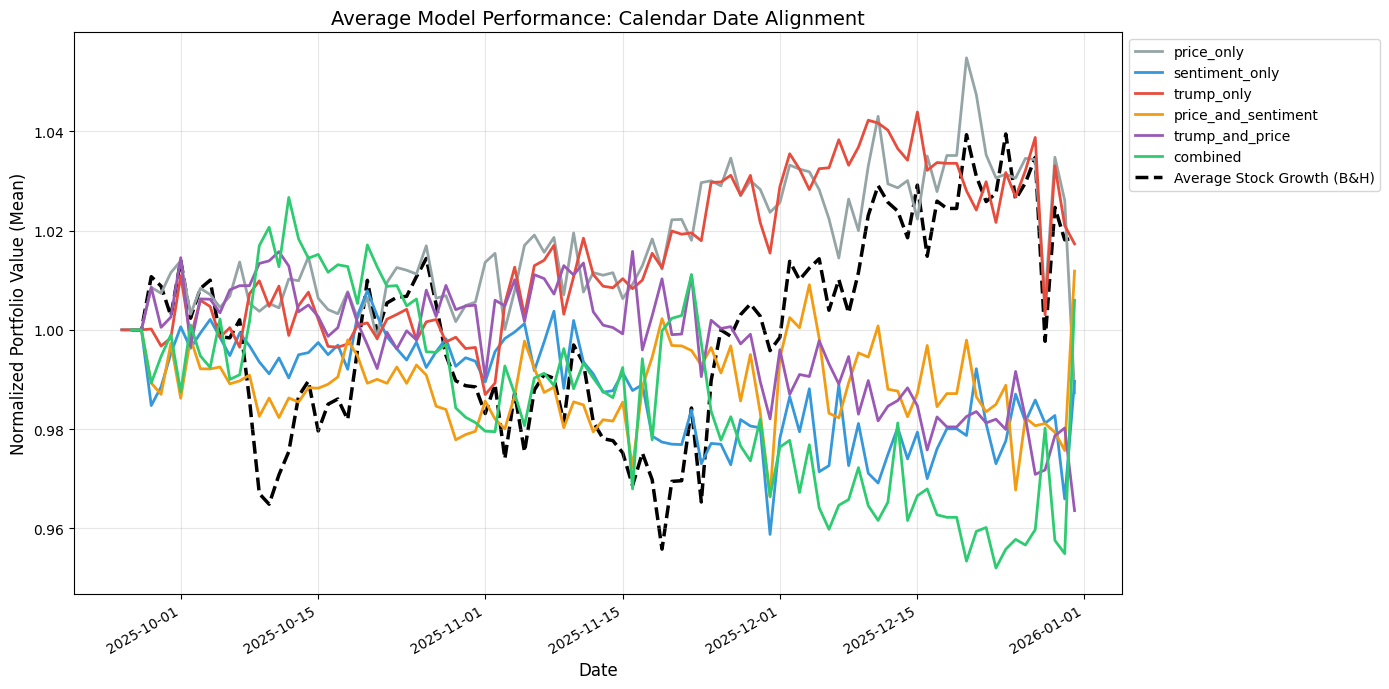

In [ ]:
plot_average_curves(final_results)

# additional graphing

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator

def plot_daily_error_bar(df, model_types=["combined", "price_only"], tickers=None, start_date=None, end_date=None):
    """
    Plots a side-by-side bar chart of absolute error per model type.
    Defaults to the average of all companies unless a specific ticker or list of tickers is provided.
    """
    def parse_series(data, is_numeric=True):
        if isinstance(data, str):
            clean = data.replace('[', '').replace(']', '').replace("'", "").replace(',', '')
            parts = [p for p in clean.split() if p.strip()]
            return np.array(parts).astype(float) if is_numeric else np.array(parts)
        return np.array(data).flatten()

    color_map = {
        "price_only": "#95a5a6",
        "sentiment_only": "#3498db",
        "trump_only": "#e74c3c",
        "price_and_sentiment": "#f39c12",
        "trump_and_price": "#9b59b6",
        "combined": "#2ecc71"
    }

    if isinstance(model_types, str):
        model_types = [model_types]

    # Handle ticker filtering logic
    if tickers is not None:
        if isinstance(tickers, str):
            tickers = [tickers]
        df = df[df["ticker"].isin(tickers)]
        title_suffix = f"for {', '.join(tickers)}"
    else:
        title_suffix = "Across All Companies"

    # Collect Data per Model
    model_averages = {}

    for m_type in model_types:
        sub = df[df["model"] == m_type]
        ticker_errors = []

        for _, row in sub.iterrows():
            try:
                dates = pd.to_datetime(parse_series(row["dates"], is_numeric=False))
                y_true = parse_series(row["y_true"])
                y_pred = parse_series(row["y_pred"])

                error_s = pd.Series(np.abs(y_pred - y_true), index=dates)

                # Date Filtering
                if start_date:
                    error_s = error_s[error_s.index >= pd.to_datetime(start_date)]
                if end_date:
                    error_s = error_s[error_s.index <= pd.to_datetime(end_date)]

                if not error_s.empty:
                    ticker_errors.append(error_s)
            except:
                continue

        if ticker_errors:
            # If multiple tickers are selected (or all), this averages them by date
            model_averages[m_type] = pd.concat(ticker_errors, axis=1).mean(axis=1).sort_index()

    if not model_averages:
        print("No data found for the specified criteria.")
        return

    master_df = pd.DataFrame(model_averages).dropna(how='all')

    # Plotting
    fig, ax = plt.subplots(figsize=(16, 8))
    n_models = len(model_types)
    x_numeric = mdates.date2num(master_df.index)
    total_width = 0.8
    bar_width = total_width / n_models

    for i, m_type in enumerate(model_types):
        if m_type not in master_df.columns: continue
        offset = (i * bar_width) - (total_width / 2)

        ax.bar(
            x_numeric + offset,
            master_df[m_type],
            width=bar_width,
            label=m_type,
            color=color_map.get(m_type),
            align='edge',
            alpha=0.85
        )

    # Formatting
    ax.xaxis_date()

    plt.title(f"Mean Absolute Error Comparison {title_suffix}", fontsize=20)
    plt.ylabel("Absolute Prediction Error", fontsize=15)
    plt.xlabel("Date", fontsize=15)
    plt.legend(title="Model Type", loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    fig.autofmt_xdate()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    plt.tight_layout()
    plt.show()

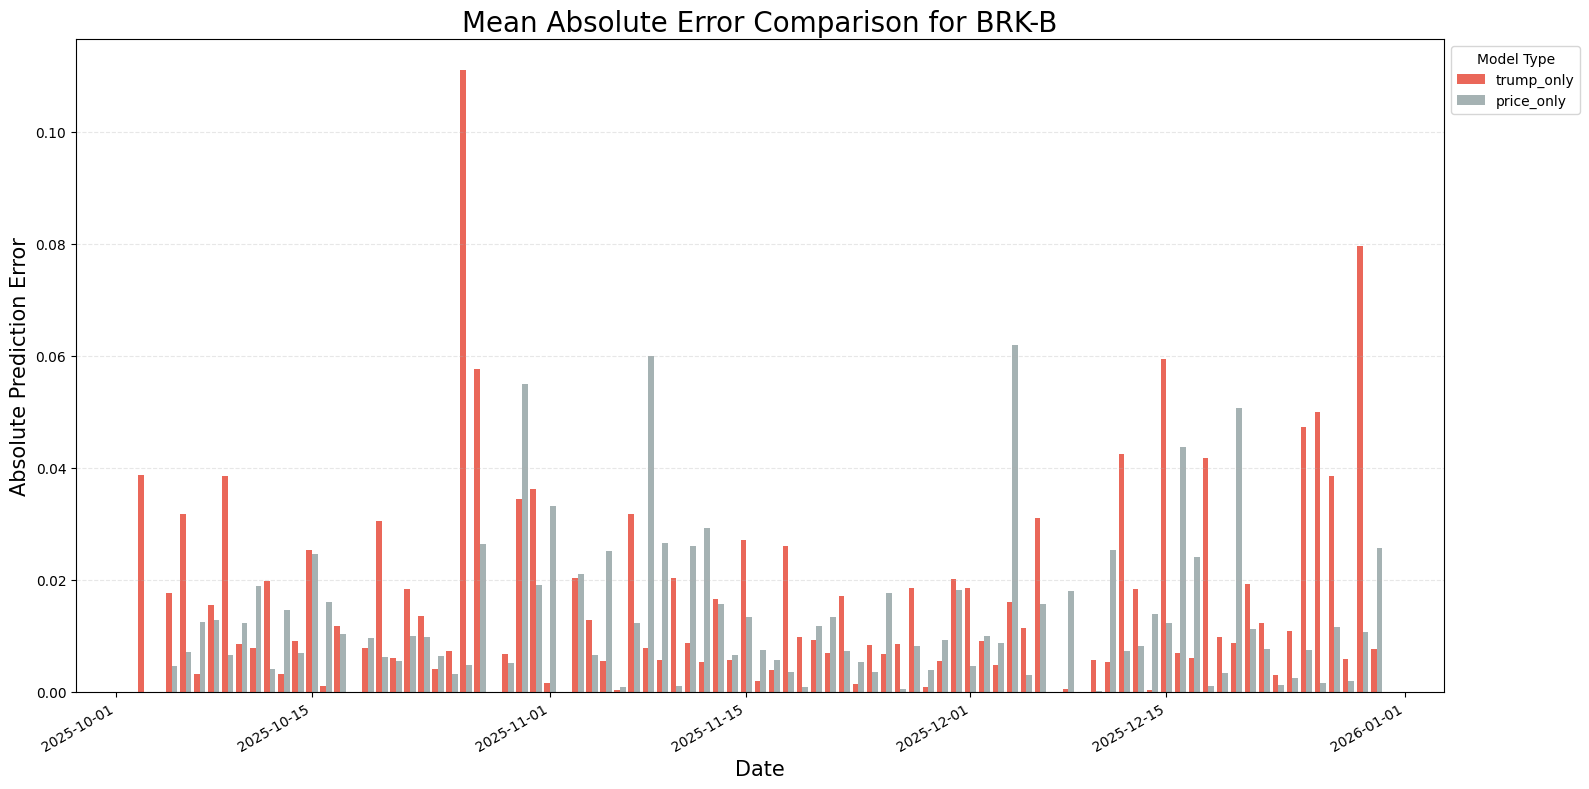

In [ ]:
plot_daily_error_bar(final_results, model_types=["trump_only", "price_only"], tickers="BRK-B", start_date=None, end_date=None)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch

def plot_model_error_difference(df, models=["combined", "price_only"], tickers=None, start_date=None, end_date=None):
    """
    Plots a bar chart showing the difference in Absolute Error between two models.
    """
    if len(models) != 2:
        print("Please provide exactly two models to compare.")
        return

    def parse_series(data, is_numeric=True):
        if isinstance(data, str):
            clean = data.replace('[', '').replace(']', '').replace("'", "").replace(',', '')
            parts = [p for p in clean.split() if p.strip()]
            return np.array(parts).astype(float) if is_numeric else np.array(parts)
        return np.array(data).flatten()

    # Ticker filtering
    if tickers:
        if isinstance(tickers, str): tickers = [tickers]
        df = df[df["ticker"].isin(tickers)]
        title_suffix = f"({', '.join(tickers)})"
    else:
        title_suffix = "(All Companies Average)"

    # Extract Error Data for both models
    model_data = {}
    for m_type in models:
        sub = df[df["model"] == m_type]
        ticker_errors = []
        for _, row in sub.iterrows():
            try:
                dates = pd.to_datetime(parse_series(row["dates"], is_numeric=False))
                abs_err = np.abs(parse_series(row["y_pred"]) - parse_series(row["y_true"]))
                s = pd.Series(abs_err, index=dates)

                if start_date: s = s[s.index >= pd.to_datetime(start_date)]
                if end_date: s = s[s.index <= pd.to_datetime(end_date)]
                ticker_errors.append(s)
            except: continue

        if ticker_errors:
            model_data[m_type] = pd.concat(ticker_errors, axis=1).mean(axis=1)

    if len(model_data) < 2:
        print("Data missing for one or both models.")
        return

    # Calculate Difference
    comparison_df = pd.DataFrame(model_data).dropna()
    diff = comparison_df[models[1]] - comparison_df[models[0]]

    # Plotting
    plt.figure(figsize=(15, 7))


    colors = ['#e74c3c' if val < 0 else '#2ecc71' for val in diff.values]

    plt.bar(diff.index, diff.values, color=colors, width=0.8, alpha=0.8)

    # Formatting
    plt.axhline(0, color='black', linewidth=1, linestyle='-') # Baseline
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

    plt.title(f"Error Difference: {models[0]} vs {models[1]} {title_suffix}", fontsize=16)
    plt.ylabel(f"$\Delta$ Absolute Error", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    legend_elements = [
    Patch(facecolor='#2ecc71', label=f'{models[0]} is Better'),
    Patch(facecolor='#e74c3c', label=f'{models[0]} is Worse')
    ]

    # Add the legend to the plot
    plt.legend(handles=legend_elements, loc='upper right')

    plt.gcf().autofmt_xdate()
    plt.tight_layout()
    plt.show()

<>:77: SyntaxWarning: invalid escape sequence '\D'
<>:77: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_5128/874094189.py:77: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel(f"$\Delta$ Absolute Error", fontsize=12)


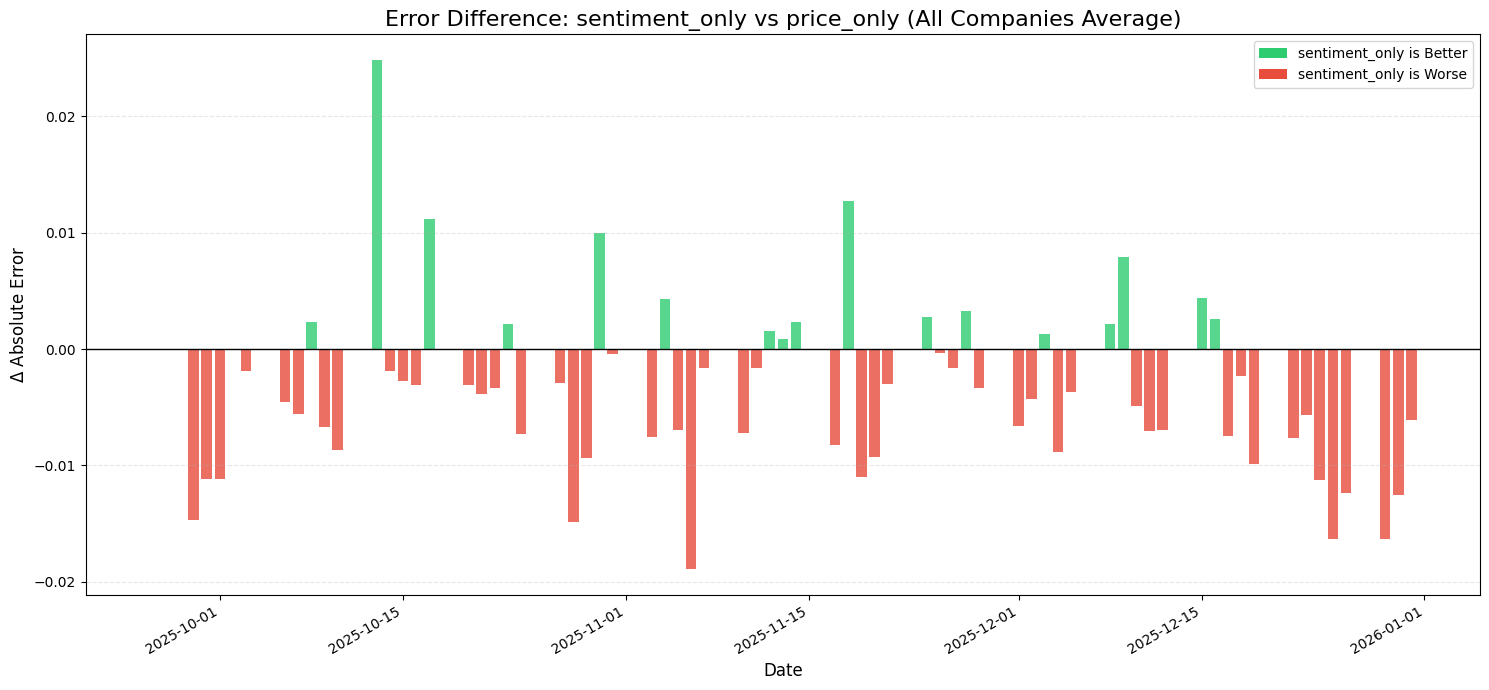

In [ ]:
plot_model_error_difference(final_results, models=["sentiment_only", "price_only"], tickers=None, start_date=None, end_date=None)